In [2]:
#import libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#This code makes use of the combined importance output from the three models available in the repository

#catbosst
catBRanking = pickle.load (open ('combined_importance_CatBoost.pkl', 'rb'))
#XGB
XGBRanking = pickle.load (open ('combined_importance_XGBoost.pkl', 'rb'))
#random forest
RFRanking = pickle.load (open ('combined_importance_RF.pkl', 'rb'))


In [4]:
#Raw df without manipulation, required for the Optuna
raw_df = pd.read_csv('C:/Users/trarg/Documents/SM/SM Experiment/DATA/pyCodes/hybrid_DDM/DATA/PDRA_Processed_Data_OS.csv') #change this path for the path of the desired dataset
#Make df: the dataset that will be used for the model
df = raw_df.copy()
#drop irrelevant driver performance features. Change this according to the desired analysis.
df = df.drop(['crash', 'minTTC', 'totalGlanceTimeOther', 'TTC'], axis = 1)

#Assign the features that will be used in the model
feature_cols = df.columns[1:].to_list()
target_col = 'reactionTime'
feature_cols.remove ('reactionTime')

In [5]:
#loop the make the combined score ranking for each feature:

rankingList = []

for feature in feature_cols:
    #get individual scores
    scoreXGB = XGBRanking.loc [XGBRanking['feature']==feature, 'combined_importance'].values[0]
    #scoreLgbm = lgbmRanking.loc [lgbmRanking['feature']==feature, 'combined_importance'].values[0]
    scoreCatBoost = catBRanking.loc [catBRanking['feature']==feature, 'combined_importance'].values[0]
    scoreRf = RFRanking.loc [RFRanking['feature']==feature, 'combined_importance'].values[0]
    #make a dictionnaire for the scores
    score_dict = {
        'feature' : feature,
        'XGBoost_score' : scoreXGB,
        #'lightGBM_score' : scoreLgbm,
        'catBoost_score' : scoreCatBoost,
        'random_forest_score' : scoreRf,
        'average_combined_score' : np.mean ([scoreXGB, scoreCatBoost,scoreRf]),
        'std_combined_score': np.std ([scoreXGB, scoreCatBoost,scoreRf]),
    }
    #append to list
    rankingList.append (score_dict)

#transform the list into a DF
combined_ranking_DF = pd.DataFrame (rankingList)

combined_ranking_DF
    

,feature,XGBoost_score,catBoost_score,random_forest_score,average_combined_score,std_combined_score
0,Gender,8.5,7.5,8.0,8.000000,0.408248
1,driverTraining,17.0,17.0,17.0,17.000000,0.000000
2,eventNumber,14.0,16.0,16.0,15.333333,0.942809
3,Age,3.5,10.0,12.0,8.500000,3.628590
4,drivingExperience,16.0,13.0,15.0,14.666667,1.247219
5,AVR,12.0,15.0,10.5,12.500000,1.870829
6,attenD,4.5,5.0,5.0,4.833333,0.235702
7,euclideanGazeDispersion,11.0,7.5,4.5,7.666667,2.656230
8,gazeEntropy,8.0,6.0,7.5,7.166667,0.849837
9,yawGazeDispersion,14.0,12.5,13.5,13.333333,0.623610


In [6]:
#sort the df
combined_ranking_DF_sorted = combined_ranking_DF.sort_values(by='average_combined_score', ascending=False)

combined_ranking_DF_sorted

,feature,XGBoost_score,catBoost_score,random_forest_score,average_combined_score,std_combined_score
1,driverTraining,17.0,17.0,17.0,17.000000,0.000000
2,eventNumber,14.0,16.0,16.0,15.333333,0.942809
4,drivingExperience,16.0,13.0,15.0,14.666667,1.247219
9,yawGazeDispersion,14.0,12.5,13.5,13.333333,0.623610
14,totalGlanceTimeOnRoad,14.0,13.5,12.0,13.166667,0.849837
5,AVR,12.0,15.0,10.5,12.500000,1.870829
10,pitchGazeDispersion,7.5,10.0,9.0,8.833333,1.027402
3,Age,3.5,10.0,12.0,8.500000,3.628590
0,Gender,8.5,7.5,8.0,8.000000,0.408248
13,totalGlanceTimeOffRoad,10.0,7.5,5.5,7.666667,1.840894


<ErrorbarContainer object of 3 artists>

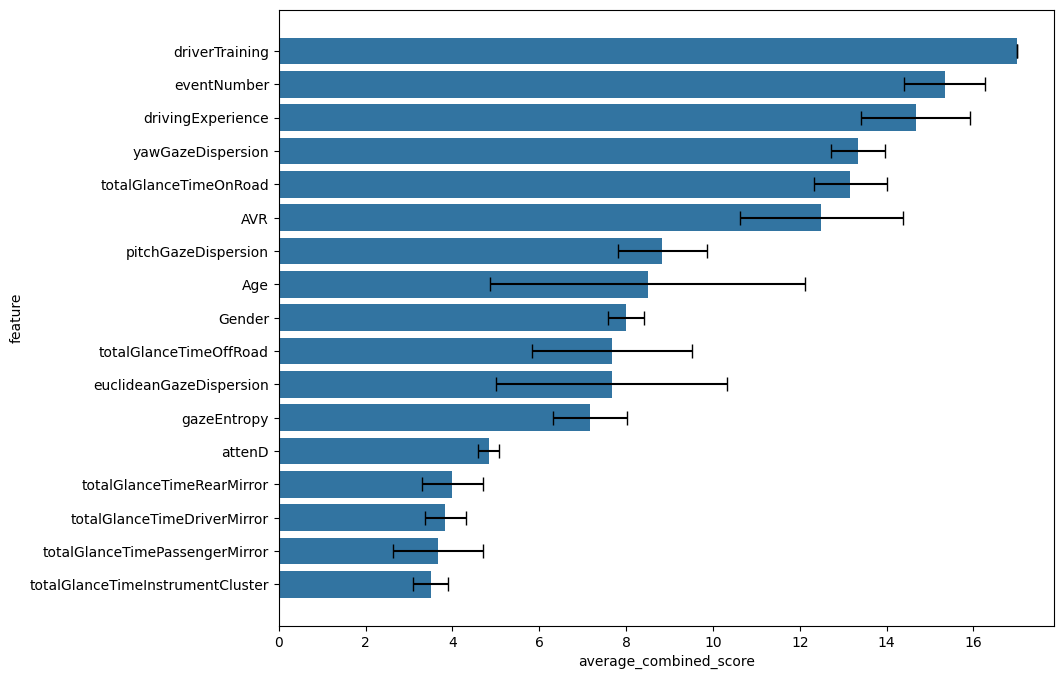

In [7]:
#make plot of final ranking

plt.figure(figsize=(10, 8))
sns.barplot(
    x='average_combined_score',
    y=combined_ranking_DF_sorted.feature,
    data=combined_ranking_DF_sorted,
)

# Add error bars manually
plt.errorbar(
    x=combined_ranking_DF_sorted['average_combined_score'],
    y=range(len(combined_ranking_DF_sorted.index)),
    xerr=combined_ranking_DF_sorted['std_combined_score'],
    fmt='none',  # Don't add any markers
    color='black',
    capsize=5
)

In [8]:
# Combine SHAP values
shap_df = pd.DataFrame({
    'Feature': list(XGBRanking.feature),
    'XGBoost': list(XGBRanking.mean_abs_shap_value),
    'CatBoost': list(catBRanking.mean_abs_shap_value),
    'Random Forest': list(RFRanking.mean_abs_shap_value),
})
shap_df

,Feature,XGBoost,CatBoost,Random Forest
0,driverTraining,0.236832,0.181229,0.131845
1,drivingExperience,0.143942,0.088757,0.047088
2,yawGazeDispersion,0.116900,0.080034,0.040617
3,eventNumber,0.103706,0.060400,0.030348
4,totalGlanceTimeOnRoad,0.100859,0.064361,0.029730
5,AVR,0.096103,0.058042,0.025026
6,euclideanGazeDispersion,0.084971,0.041932,0.020666
7,totalGlanceTimeOffRoad,0.081090,0.036828,0.017700
8,Gender,0.073110,0.035100,0.015399
9,gazeEntropy,0.078560,0.029819,0.037706


In [9]:
# Combine PFI values
pfi_df = pd.DataFrame({
    'Feature': list(XGBRanking.feature),
    'XGBoost': list(XGBRanking.PFI_values_mean),
    'CatBoost': list(catBRanking.PFI_values_mean),
    'Random Forest': list(RFRanking.PFI_values_mean),
})
pfi_df

,Feature,XGBoost,CatBoost,Random Forest
0,driverTraining,0.382986,0.252162,0.179287
1,drivingExperience,0.319098,0.157644,0.054622
2,yawGazeDispersion,0.149186,0.155610,0.041659
3,eventNumber,0.162832,0.077584,0.027130
4,totalGlanceTimeOnRoad,0.175857,0.024995,0.013587
5,AVR,0.122624,0.058332,0.023400
6,euclideanGazeDispersion,0.061306,0.023457,0.005622
7,totalGlanceTimeOffRoad,0.047062,0.023879,0.005432
8,Gender,0.038849,0.007166,0.004879
9,gazeEntropy,0.003369,0.008253,-0.025237


In [10]:
# Optional: sort features by average SHAP/PFI
order_rank = combined_ranking_DF_sorted.set_index('feature').sort_values(by = 'average_combined_score', ascending=False).index


shap_long = shap_df.melt(id_vars='Feature', var_name='Model', value_name='SHAP Value')
pfi_long = pfi_df.melt(id_vars='Feature', var_name='Model', value_name='PFI Value')

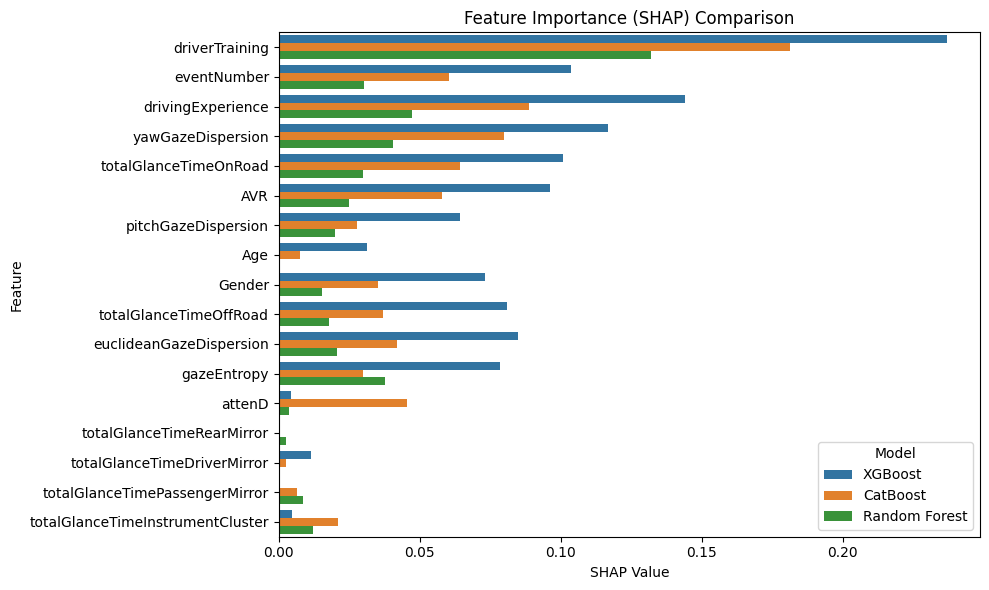

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=shap_long, y='Feature', x='SHAP Value', hue='Model', order=order_rank)
plt.title('Feature Importance (SHAP) Comparison')
plt.tight_layout()
plt.show()

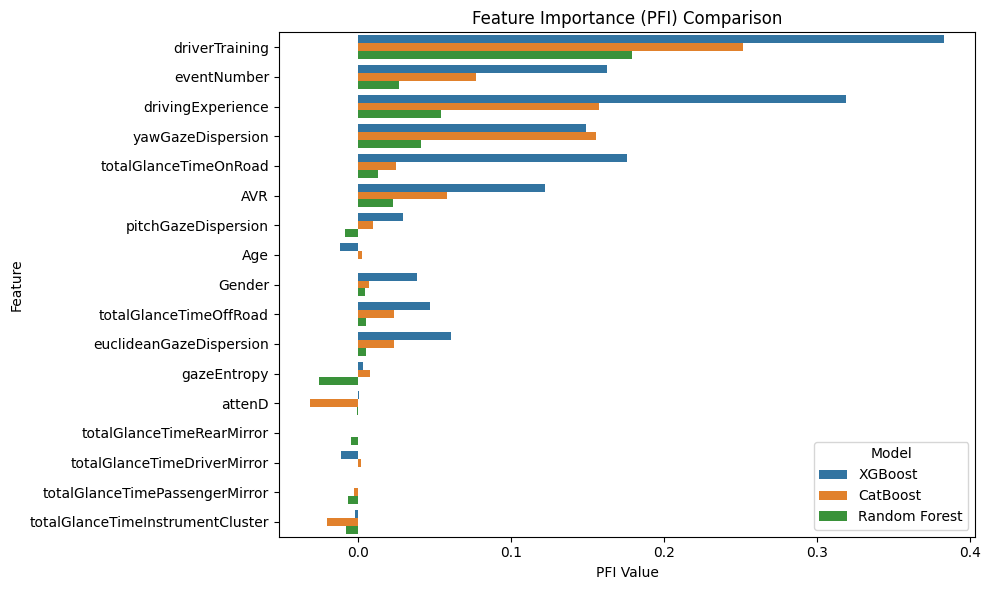

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=pfi_long, y='Feature', x='PFI Value', hue='Model', order=order_rank)
plt.title('Feature Importance (PFI) Comparison')
plt.tight_layout()
plt.show()